In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import warnings
from itertools import islice
warnings.filterwarnings('ignore')


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)




In [6]:
categories = {
    "Electronics": "raw_review_Electronics",
    "Books": "raw_review_Books",
    "Beauty": "raw_review_All_Beauty"
}

samples_per_category = 33_000  # nearly 100k rewiews in total

all_dfs = []

for category_name, hf_config in categories.items():
    print(f"\n {category_name} downloading...")
    
    
    dataset = load_dataset(
        "McAuley-Lab/Amazon-Reviews-2023",
        hf_config,
        split="full",
        streaming=True,
        trust_remote_code=True
    )
    
    
    samples = list(islice(dataset, samples_per_category))
    
    
    df_cat = pd.DataFrame(samples)
    df_cat['category'] = category_name
    
    all_dfs.append(df_cat)
    print(f" {category_name}: {len(df_cat):,} rewievs")

# Hepsini birleştir
df = pd.concat(all_dfs, ignore_index=True)

print(f"\n total rewievs: {len(df):,}")
print(f" Columns: {df.columns.tolist()}")
print(f" Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


 Electronics downloading...
 Electronics: 33,000 rewievs

 Books downloading...
 Books: 33,000 rewievs

 Beauty downloading...
 Beauty: 33,000 rewievs

 total rewievs: 99,000
 Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'category']
 Memory: 105.9 MB


In [7]:
print(f"Column Number: {len(df.columns)}")
print(f"Row Number: {len(df)}")
print(f"/n---- First 3 rows ----")
print(df.head(3))

Column Number: 11
Row Number: 99000
/n---- First 3 rows ----
   rating                                    title  \
0     3.0        Smells like gasoline! Going back!   
1     1.0  Didn’t work at all lenses loose/broken.   
2     5.0                               Excellent!   

                                                text  \
0  First & most offensive: they reek of gasoline ...   
1  These didn’t work. Idk if they were damaged in...   
2  I love these. They even come with a carry case...   

                                              images        asin parent_asin  \
0  [{'small_image_url': 'https://m.media-amazon.c...  B083NRGZMM  B083NRGZMM   
1                                                 []  B07N69T6TM  B07N69T6TM   
2                                                 []  B01G8JO5F2  B01G8JO5F2   

                        user_id      timestamp  helpful_vote  \
0  AFKZENTNBQ7A7V7UXW5JJI6UGRYQ  1658185117948             0   
1  AFKZENTNBQ7A7V7UXW5JJI6UGRYQ  1592678549731  

In [8]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99000 entries, 0 to 98999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             99000 non-null  float64
 1   title              99000 non-null  object 
 2   text               99000 non-null  object 
 3   images             99000 non-null  object 
 4   asin               99000 non-null  object 
 5   parent_asin        99000 non-null  object 
 6   user_id            99000 non-null  object 
 7   timestamp          99000 non-null  int64  
 8   helpful_vote       99000 non-null  int64  
 9   verified_purchase  99000 non-null  bool   
 10  category           99000 non-null  object 
dtypes: bool(1), float64(1), int64(2), object(7)
memory usage: 7.6+ MB


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,category
count,99000.000000,99000,99000,99000,99000,99000,99000,9.900000e+04,99000.000000,99000,99000
unique,NaN,72814,94242,6385,75344,72874,30206,NaN,NaN,2,3
top,NaN,Five Stars,Good,[],B007IAE5WY,B085BB7B1M,AFWVN52MRBWOTIK7UGXBWGOY4HBA,NaN,NaN,True,Electronics
freq,NaN,5118,136,92588,126,126,2805,NaN,NaN,68003,33000
mean,4.247424,NaN,NaN,NaN,NaN,NaN,NaN,1.518817e+12,1.836939,NaN,NaN
std,1.202950,NaN,NaN,NaN,NaN,NaN,NaN,1.207520e+11,16.288088,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,8.739193e+11,0.000000,NaN,NaN
25%,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.456340e+12,0.000000,NaN,NaN
50%,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.547234e+12,0.000000,NaN,NaN
75%,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.608935e+12,1.000000,NaN,NaN


In [11]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': df.isnull().mean() * 100
}).sort_values(by='missing_percent', ascending=False)

missing = missing[missing['missing_percent'] > 0].sort_values(by='missing_percent', ascending=False)

if len(missing) > 0:
    print("\nMissing Values:")
    print(missing)
else:
    print("\nNo missing values found.")




No missing values found.


In [12]:
print("Empty string control:")
for col in ['title', 'text']:
    empty_count = (df[col].astype(str).str.strip() == '').sum()
    print(f" {col}: {empty_count} empty strings")

Empty string control:
 title: 0 empty strings
 text: 13 empty strings


In [17]:
hashable_cols = ['rating', 'title', 'text', 'asin', 'parent_asin', 
                 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'category']

exact_dup = df.duplicated(subset=hashable_cols).sum()
print(f"\nExact duplicate rows: {exact_dup}")

text_dup = df.duplicated(subset=['text']).sum()
print(f"Duplicate reviews based on 'text': {text_dup}")

user_product_dup = df.duplicated(subset=['user_id', 'asin']).sum()
print(f"Duplicate of same user + product: {user_product_dup}")


Exact duplicate rows: 95
Duplicate reviews based on 'text': 4758
Duplicate of same user + product: 95


In [18]:
rating_dist = df['rating'].value_counts().sort_index()
print("Rating distribution:")
print(rating_dist)
print(f"\nRating distribution (percent):")
print((rating_dist / len(df) * 100).round(2))



Rating distribution:
rating
1.0     6728
2.0     4529
3.0     8458
4.0    17090
5.0    62195
Name: count, dtype: int64

Rating distribution (percent):
rating
1.0     6.80
2.0     4.57
3.0     8.54
4.0    17.26
5.0    62.82
Name: count, dtype: float64


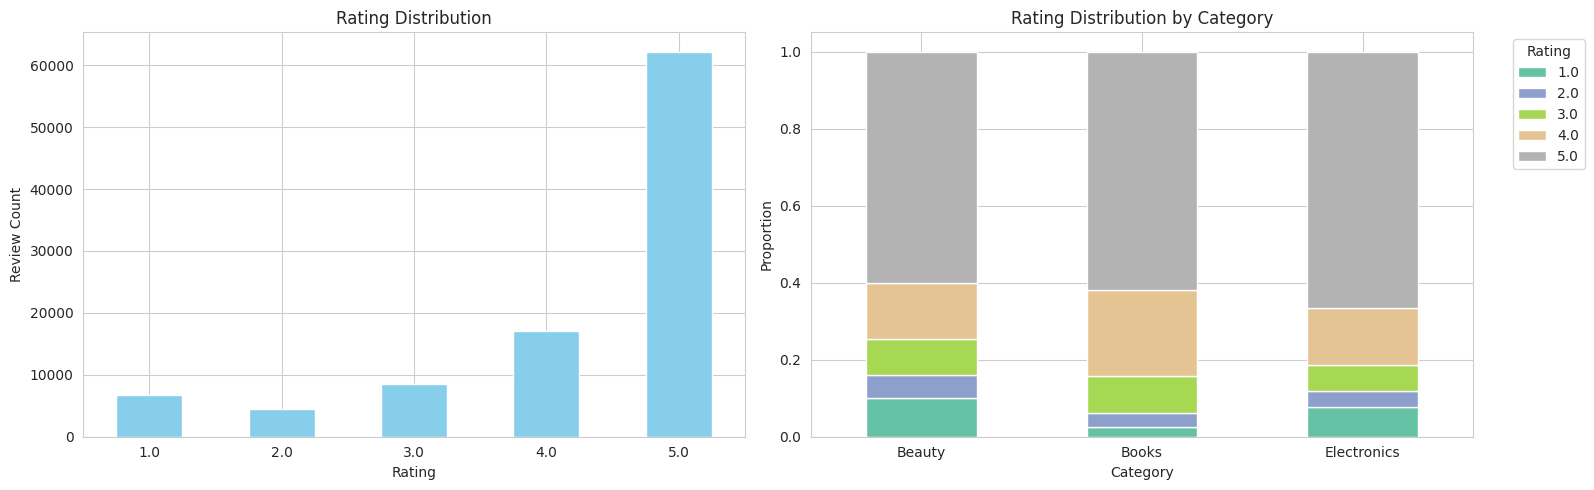

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Review Count')
axes[0].tick_params(axis='x', rotation=0)

rating_by_category = df.groupby('category')['rating'].value_counts(normalize=True).unstack()
rating_by_category.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title('Rating Distribution by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Proportion')
axes[1].legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('/home/mini/projects/review-intelligence-system/reports/figures/rating_distribution.png')
plt.show()


Text length statistics:
count    99000.000000
mean       510.968303
std        800.972138
min          0.000000
25%         76.000000
50%        209.000000
75%        568.000000
max      23991.000000
Name: text_length, dtype: float64

Word count statistics:
count    99000.000000
mean        91.443081
std        138.706214
min          0.000000
25%         14.000000
50%         39.000000
75%        105.000000
max       4091.000000
Name: word_count, dtype: float64


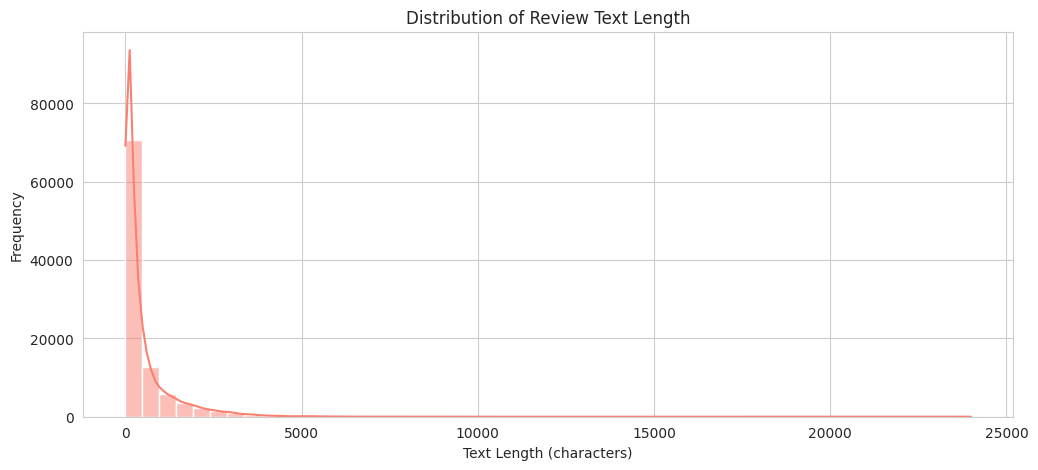

In [22]:
df['text_length'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

print("\nText length statistics:")
print(df['text_length'].describe())
print("\nWord count statistics:")
print(df['word_count'].describe())

plt.figure(figsize=(12, 5))
sns.histplot(df['text_length'], bins=50, kde=True, color='salmon')
plt.title('Distribution of Review Text Length')
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')
plt.savefig('/home/mini/projects/review-intelligence-system/reports/figures/text_length.png')
plt.show()

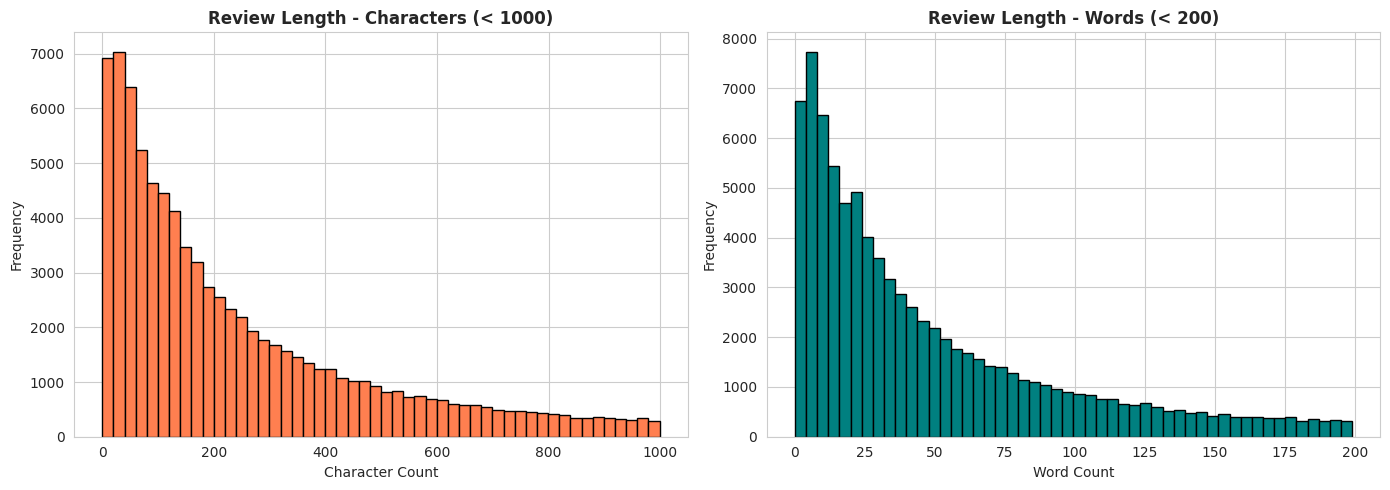


Category-based average review length:
             text_length  word_count
category                            
Beauty             236.5        44.5
Books              869.7       151.1
Electronics        426.8        78.7


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['text_length'] < 1000]['text_length'].hist(
    bins=50, ax=axes[0], color='coral', edgecolor='black'
)
axes[0].set_title('Review Length - Characters (< 1000)', fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')

# Word distribution
df[df['word_count'] < 200]['word_count'].hist(
    bins=50, ax=axes[1], color='teal', edgecolor='black'
)
axes[1].set_title('Review Length - Words (< 200)', fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('/home/mini/projects/review-intelligence-system/reports/figures/02_review_length.png', dpi=100, bbox_inches='tight')
plt.show()

# Kategori bazında ortalama uzunluk
print("\nCategory-based average review length:")
print(df.groupby('category')[['text_length', 'word_count']].mean().round(1))

In [24]:
print("Helpful vote distribution:")
print(df['helpful_vote'].describe())

print(f"\nHelpful vote = 0 reviews: {(df['helpful_vote'] == 0).sum():,} ({(df['helpful_vote'] == 0).mean()*100:.1f}%)")
print(f"Helpful vote > 10 reviews: {(df['helpful_vote'] > 10).sum():,}")


Helpful vote distribution:
count    99000.000000
mean         1.836939
std         16.288088
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max       3580.000000
Name: helpful_vote, dtype: float64

Helpful vote = 0 reviews: 66,180 (66.8%)
Helpful vote > 10 reviews: 3,133


In [26]:
print("Verified purchase distribution:")
print(df['verified_purchase'].value_counts())
print(f"\nVerified purchase = True: {(df['verified_purchase'] == True).sum():,} ({(df['verified_purchase'] == True).mean()*100:.1f}%)")

print("\nVerified purchase rating average:")
print(df.groupby('verified_purchase')['rating'].mean().round(3))

Verified purchase distribution:
verified_purchase
True     68003
False    30997
Name: count, dtype: int64

Verified purchase = True: 68,003 (68.7%)

Verified purchase rating average:
verified_purchase
False    4.285
True     4.230
Name: rating, dtype: float64


In [28]:
df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')
df['review_year'] = df['datetime'].dt.year
df['review_month'] = df['datetime'].dt.to_period('M')

print(f"Date Interval: {df['datetime'].min()} → {df['datetime'].max()}")
print("\nReviews per year:")
print(df['review_year'].value_counts().sort_index().tail(10))


Date Interval: 1997-09-10 19:22:25 → 2023-03-20 07:38:54.741000

Reviews per year:
review_year
2014     4526
2015     6570
2016     8304
2017     8198
2018     9049
2019    11714
2020    13711
2021    12935
2022     9947
2023     1592
Name: count, dtype: int64


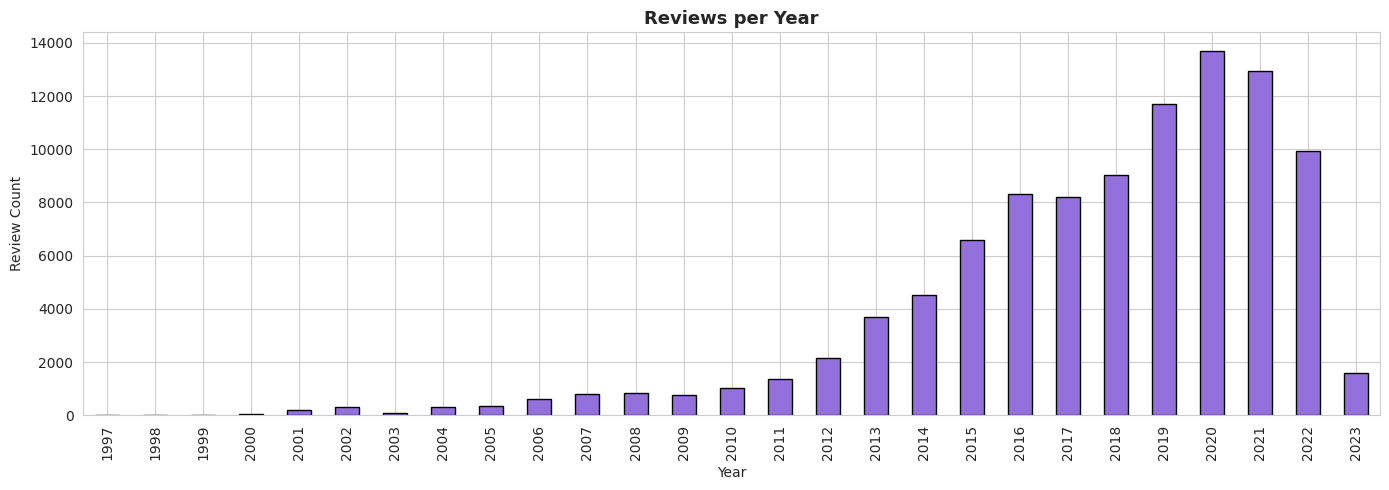

In [30]:
fig, ax = plt.subplots(figsize=(14, 5))
yearly = df['review_year'].value_counts().sort_index()
yearly.plot(kind='bar', color='mediumpurple', edgecolor='black', ax=ax)
ax.set_title('Reviews per Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Review Count')
plt.tight_layout()
plt.savefig('/home/mini/projects/review-intelligence-system/reports/figures/03_yearly_trend.png', dpi=100, bbox_inches='tight')
plt.show()

In [31]:
print("="*80)
print("Sample reviews from every rating:")
print("="*80)

for rating in sorted(df['rating'].unique()):
    sample = df[df['rating'] == rating].sample(1, random_state=42).iloc[0]
    print(f"\nRating {rating} | Category: {sample['category']}")
    print(f" Title: {sample['title']}")
    print(f" Text: {sample['text'][:300]}...")
    print("-"*80)
    

Sample reviews from every rating:

Rating 1.0 | Category: Beauty
 Title: TWISTED, CURLY & DISAPPOINTED & EXPENSIVE
 Text: Extremely expensive item. It’s hard plastic, hard to roll hair into it, difficult to secure with the band, won’t stay in hair. There are 2 rollers & 2 skinny rubber bands described as 4 pieces for $10.99...
--------------------------------------------------------------------------------

Rating 2.0 | Category: Beauty
 Title: Not one size fits all
 Text: I wish it was tighter so it won't slide off my head...
--------------------------------------------------------------------------------

Rating 3.0 | Category: Books
 Title: A decent starter book for your first ice cream machine...
 Text: The self-proclaimed "Ultimate Ice Cream Book" is stated to contain over 500 recipes for ice cream, sherbert, sorbet, granita, drinks and more, but this number is extremely misleading; there are really several basic bases (chocolate, vanilla, various fruits) with extensive lists of f

In [33]:
longest = df.loc[df['text_length'].idxmax()]
print("\nLongest review:")
print(f"Rating: {longest['rating']} | Category: {longest['category']}")
print(f"Title: {longest['title']}")
print(f"Text: {longest['text'][:500]}...")



Longest review:
Rating: 5.0 | Category: Books
Title: #8 in in the series
Text: If Raymond Chandler's Sam Spade where a Philadelphia lawyer circa 1995 he would be Victor Carl. The humor is dry, the dialogue sparkling and the writing keeps you wanting more. Lashner is a new to me author and I was so entertained I am going back to the library to find the other titles in the series that first opened 20 years ago. Having gone to college near Philadelphia sweetened the story for me. As I was new to the series I went and looked up the summaries for the 7 earlier titles to give me...


In [39]:
print("="*60)
print("EDA completed, review insights - Amazon Reviews 2023 - Analysis")
print("="*60)

print("\nData Size:")
print(f" Total reviews: {len(df):,}")
print(f"Categories: {df['category'].value_counts().to_dict()}")
print(f" Date range: {df['datetime'].min().date()} → {df['datetime'].max().date()}")

print(f" Target(Rating):")
print(f" Average rating: {df['rating'].mean():.2f}")
print(f" Rating distribution:\n{df['rating'].value_counts().sort_index()}")
print(f"There is an imbalance towards higher ratings, with 5-star reviews being the most common.")

print(f" Text Features:")
print(f" Average text length: {df['text_length'].mean():.2f}")
print(f" Text length distribution:\n{df['text_length'].value_counts().sort_index()}")
print(f" Average word count: {df['word_count'].mean():.2f}")
print(f" Word count distribution:\n{df['word_count'].value_counts().sort_index()}")
print(f" Reviews are generally short, with a long tail of longer reviews.")

print(f"Trust Signals:")
print(f" Average helpful votes: {df['helpful_vote'].mean():.2f}")
print(f" Helpful votes distribution:\n{df['helpful_vote'].value_counts().sort_index()}")
print(f" Verified purchase distribution:\n{df['verified_purchase'].value_counts()}")

print(f" Data Quality:")
print(f" Missing values: {df.isnull().sum().sum()}")
print(f" Exact duplicates: {df.duplicated(subset=['rating', 'title', 'text', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'category']).sum()}")
print(f" Text duplicates: {df.duplicated(subset=['text']).sum()}")
print(f" User-product duplicates: {df.duplicated(subset=['user_id', 'asin']).sum()}")


EDA completed, review insights - Amazon Reviews 2023 - Analysis

Data Size:
 Total reviews: 99,000
Categories: {'Electronics': 33000, 'Books': 33000, 'Beauty': 33000}
 Date range: 1997-09-10 → 2023-03-20
 Target(Rating):
 Average rating: 4.25
 Rating distribution:
rating
1.0     6728
2.0     4529
3.0     8458
4.0    17090
5.0    62195
Name: count, dtype: int64
There is an imbalance towards higher ratings, with 5-star reviews being the most common.
 Text Features:
 Average text length: 510.97
 Text length distribution:
text_length
0          1
1         65
2        178
3         59
4        414
        ... 
13663      1
15430      1
15674      1
16824      1
23991      1
Name: count, Length: 4258, dtype: int64
 Average word count: 91.44
 Word count distribution:
word_count
0         13
1       1751
2       3152
3       1840
4       2080
        ... 
2267       1
2560       1
2572       1
2782       1
4091       1
Name: count, Length: 1079, dtype: int64
 Reviews are generally short, with

In [40]:
processed_path = '/home/mini/projects/review-intelligence-system/data/processed/amazon_eda_enriched.csv'
df.to_csv(processed_path, index=False)
print(f"\nEnriched dataset saved to: {processed_path}")
print(f"Size: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")



Enriched dataset saved to: /home/mini/projects/review-intelligence-system/data/processed/amazon_eda_enriched.csv
Size: 118.6 MB
